# Brain Tumor Image Classification

## Project Overview

This notebook builds a complete image classification pipeline to detect and classify brain tumors from MRI images.

**Classes:**
- `glioma_tumor` — A type of tumor that occurs in the brain and spinal cord
- `meningioma_tumor` — A tumor that arises from the meninges
- `pituitary_tumor` — A tumor that forms in the pituitary gland
- `no_tumor` — Healthy brain scan with no tumor present

**Pipeline:**
1. Load and explore data
2. Preprocess images
3. Train multiple models
4. Evaluate and compare
5. Predict on test data

---

## 1. Import Libraries

In [9]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn — models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model persistence
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Configuration

All path and hyperparameter settings are centralized here for easy modification.

In [10]:
# ---------------------------------------------------------------
# CONFIGURATION — modify these values to match your environment
# ---------------------------------------------------------------

# Folder paths
TRAIN_FOLDER = r"C:\Users\HP\OneDrive\Desktop\kagg_pro\train"
TEST_FOLDER  = r"C:\Users\HP\OneDrive\Desktop\kagg_pro\test"

# Image settings
IMG_SIZE     = (64, 64)   # Width x Height — increase to (128,128) for better accuracy
                           # but requires more RAM and training time

# Model settings
RANDOM_STATE = 42          # Seed for reproducibility
TEST_SIZE    = 0.2         # 20% of train data used for validation
N_COMPONENTS = 100         # PCA components — reduces dimensionality before modeling

# Label keywords mapped to class names
# These strings are searched inside each filename
LABEL_MAP = {
    "glioma_tumor"    : "glioma",
    "meningioma_tumor": "meningioma",
    "pituitary_tumor" : "pituitary",
    "no_tumor"        : "no_tumor"
}

print("Configuration loaded.")
print(f"  Train folder : {TRAIN_FOLDER}")
print(f"  Test  folder : {TEST_FOLDER}")
print(f"  Image size   : {IMG_SIZE}")

Configuration loaded.
  Train folder : C:\Users\HP\OneDrive\Desktop\kagg_pro\train
  Test  folder : C:\Users\HP\OneDrive\Desktop\kagg_pro\test
  Image size   : (64, 64)


## 3. Data Loading

Labels are extracted directly from filenames since the CSV was empty.
Each filename contains a keyword such as `glioma_tumor` or `no_tumor`.

In [11]:
def extract_label(filename):
    """
    Extract class label from a filename by checking for known keywords.

    Parameters
    ----------
    filename : str
        Name of the image file (e.g. '00001_gg_glioma_tumor.png')

    Returns
    -------
    str or None
        Class label string, or None if no known keyword is found
    """
    for keyword, label in LABEL_MAP.items():
        if keyword in filename:
            return label
    return None


def load_images_from_folder(folder, img_size=IMG_SIZE):
    """
    Read all images from a folder, resize them, flatten to 1D,
    and extract labels from filenames.

    Parameters
    ----------
    folder   : str   — path to the image folder
    img_size : tuple — (width, height) to resize every image

    Returns
    -------
    X         : np.ndarray, shape (n_samples, width*height*3)
    y         : np.ndarray, shape (n_samples,) — string labels
    filenames : list of str
    """
    X, y, filenames = [], [], []
    skipped = 0

    all_files = sorted(os.listdir(folder))
    print(f"Found {len(all_files)} files in '{os.path.basename(folder)}'")

    for i, fname in enumerate(all_files):

        # Skip non-image files
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            skipped += 1
            continue

        label = extract_label(fname)
        if label is None:
            skipped += 1
            continue

        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path)

        if img is None:
            skipped += 1
            continue

        # Resize and normalize pixel values to [0, 1]
        img = cv2.resize(img, img_size)
        img = img.flatten() / 255.0

        X.append(img)
        y.append(label)
        filenames.append(fname)

        if (i + 1) % 500 == 0:
            print(f"  Loaded {i+1}/{len(all_files)} ...")

    print(f"  Done. Loaded: {len(X)} | Skipped: {skipped}")
    return np.array(X), np.array(y), filenames


# Load training data
print("Loading TRAIN images...")
X_train_full, y_train_full, train_files = load_images_from_folder(TRAIN_FOLDER)

# Load test data
print("\nLoading TEST images...")
X_test_raw, y_test_raw, test_files = load_images_from_folder(TEST_FOLDER)

print(f"\nTrain set shape : {X_train_full.shape}")
print(f"Test  set shape : {X_test_raw.shape}")

Loading TRAIN images...
Found 2007 files in 'train'
  Loaded 500/2007 ...
  Loaded 1000/2007 ...
  Loaded 1500/2007 ...
  Loaded 2000/2007 ...
  Done. Loaded: 2007 | Skipped: 0

Loading TEST images...
Found 863 files in 'test'
  Loaded 500/863 ...
  Done. Loaded: 863 | Skipped: 0

Train set shape : (2007, 12288)
Test  set shape : (863, 12288)


## 4. Exploratory Data Analysis

Before training, we inspect class distribution and visualize sample images.

In [12]:
import os

TEST_FOLDER = r"C:\Users\HP\OneDrive\Desktop\kagg_pro\test"

files = os.listdir(TEST_FOLDER)
print(f"Total files in test folder: {len(files)}")
print("\nFirst 10 files:")
for f in files[:10]:
    print(f)

Total files in test folder: 863

First 10 files:
00000_image(32)_no_tumor.png
00001_p (236)_pituitary_tumor.png
00002_m3 (244)_meningioma_tumor.png
00003_image(60)_no_tumor.png
00004_p (34)_pituitary_tumor.png
00005_m (102)_meningioma_tumor.png
00006_m1(106)_meningioma_tumor.png
00007_p (475)_pituitary_tumor.png
00008_p (713)_pituitary_tumor.png
00009_m2 (76)_meningioma_tumor.png


Training set class distribution:
label
pituitary     578
glioma        578
meningioma    575
no_tumor      276
Name: count, dtype: int64

Test set class distribution:
label
pituitary     249
glioma        248
meningioma    247
no_tumor      119
Name: count, dtype: int64


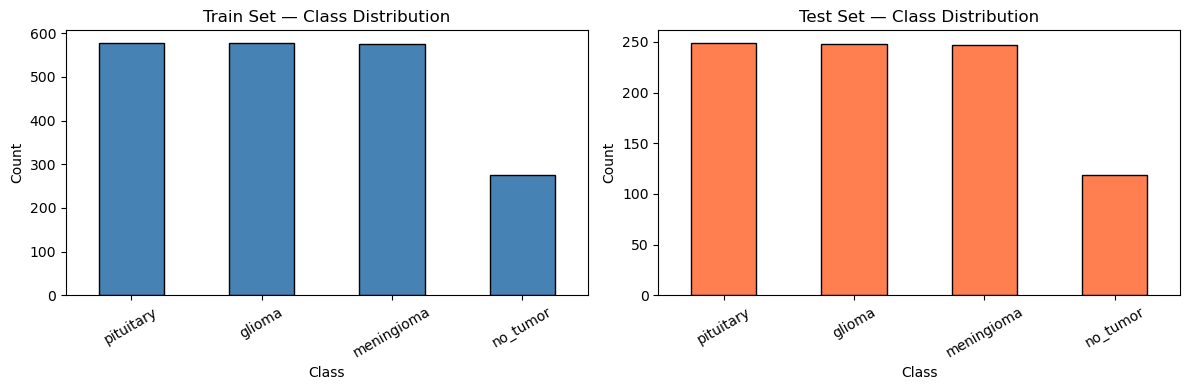

In [13]:
# ---- Class distribution ----
train_series = pd.Series(y_train_full, name="label")
test_series  = pd.Series(y_test_raw,   name="label")

print("Training set class distribution:")
print(train_series.value_counts())
print("\nTest set class distribution:")
print(test_series.value_counts())

# ---- Plot class distribution ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_series.value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title("Train Set — Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

test_series.value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title("Test Set — Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

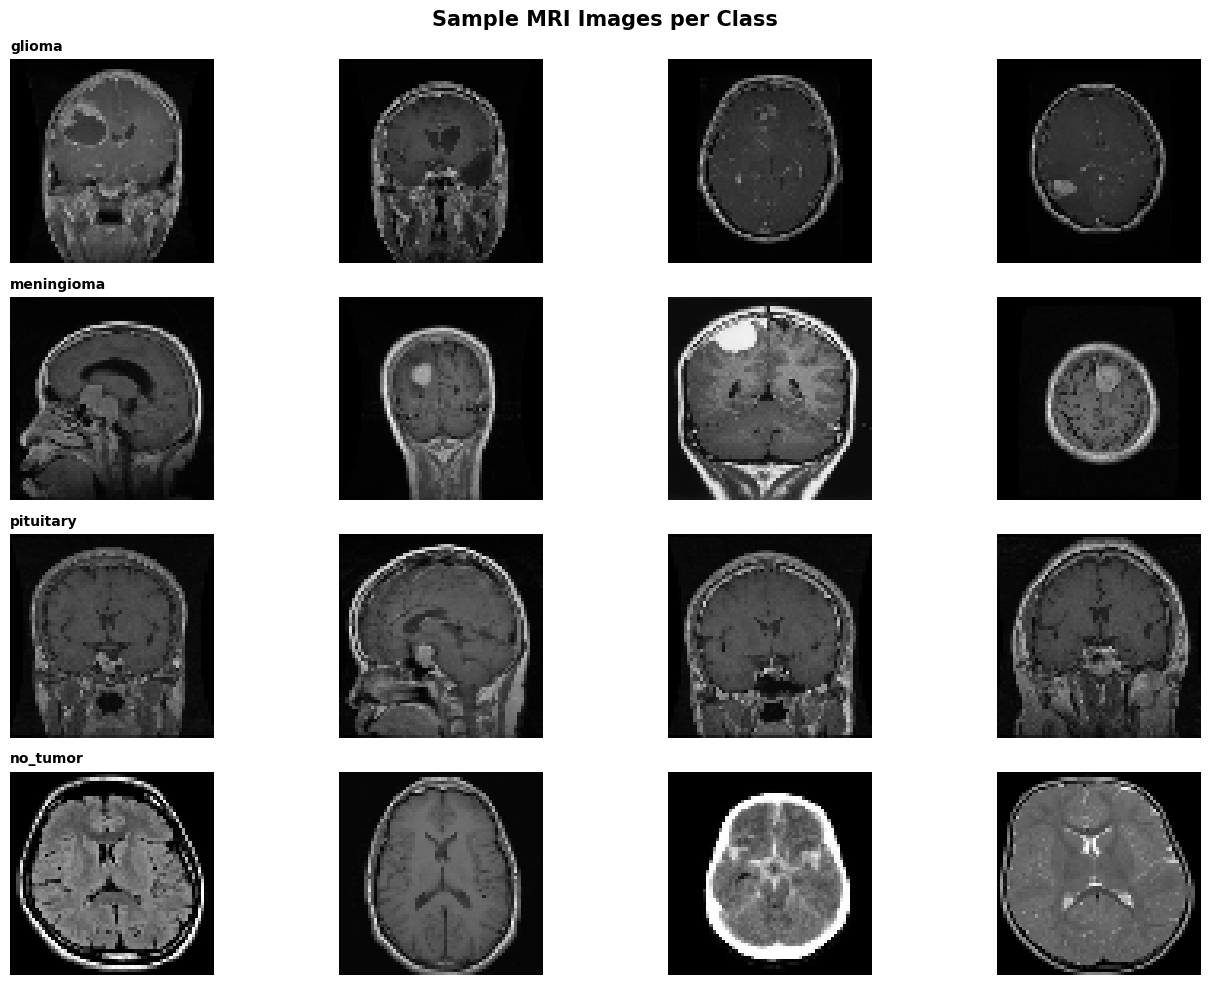

In [15]:
# ---- Visualize sample images from each class ----

classes     = list(LABEL_MAP.values())   # ['glioma', 'meningioma', 'pituitary', 'no_tumor']
samples_per = 4

fig, axes = plt.subplots(len(classes), samples_per, figsize=(14, 10))
fig.suptitle("Sample MRI Images per Class", fontsize=15, fontweight='bold')

for row, cls in enumerate(classes):
    # Find indices belonging to this class
    indices = np.where(y_train_full == cls)[0]
    chosen  = indices[:samples_per]

    for col, idx in enumerate(chosen):
        # Reshape the flattened image back to (H, W, 3)
        img = X_train_full[idx].reshape(IMG_SIZE[0], IMG_SIZE[1], 3)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

## 5. Preprocessing

Steps:
1. Encode string labels to integers
2. Split training data into train/validation sets
3. Apply PCA to reduce feature dimensions (64x64x3 = 12288 features is too large for SVM/KNN)

In [16]:
# ---- Label encoding ----
# Converts string labels ('glioma', etc.) to integers (0, 1, 2, 3)
le = LabelEncoder()
y_encoded     = le.fit_transform(y_train_full)
y_test_encoded = le.transform(y_test_raw)

print("Label encoding mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

# ---- Train / Validation split ----
# We split the training folder into train + validation
# The test folder is held out entirely for final evaluation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_encoded,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y_encoded    # maintain class proportion in both splits
)

print(f"\nTrain      : {X_tr.shape[0]} samples")
print(f"Validation : {X_val.shape[0]} samples")
print(f"Test       : {X_test_raw.shape[0]} samples")

Label encoding mapping:
  0 -> glioma
  1 -> meningioma
  2 -> no_tumor
  3 -> pituitary

Train      : 1605 samples
Validation : 402 samples
Test       : 863 samples


PCA: 100 components explain 72.1% of total variance


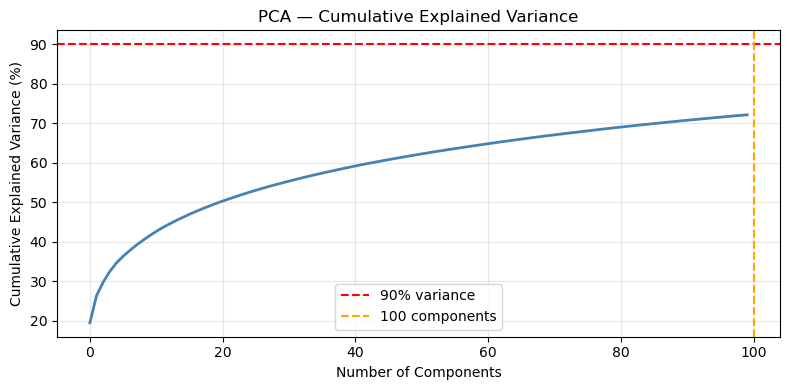

In [17]:
# ---- PCA (Principal Component Analysis) ----
#
# Raw images have 64*64*3 = 12,288 features per sample.
# PCA reduces this to N_COMPONENTS while retaining maximum variance.
# This speeds up SVM and KNN significantly and often improves accuracy.

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

# Fit on training data only — never fit on validation or test data
X_tr_pca  = pca.fit_transform(X_tr)
X_val_pca = pca.transform(X_val)
X_tst_pca = pca.transform(X_test_raw)

explained = pca.explained_variance_ratio_.sum() * 100
print(f"PCA: {N_COMPONENTS} components explain {explained:.1f}% of total variance")

# Plot cumulative explained variance to justify component count
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(8, 4))
plt.plot(cumvar, color='steelblue', linewidth=2)
plt.axhline(y=90, color='red', linestyle='--', label='90% variance')
plt.axvline(x=N_COMPONENTS, color='orange', linestyle='--', label=f'{N_COMPONENTS} components')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Model Training

We train four different models and compare their validation accuracy:

| Model | Strengths |
|---|---|
| Random Forest | Robust, handles noise, fast |
| SVM (RBF Kernel) | High accuracy on image features |
| Gradient Boosting | Strong ensemble method |
| K-Nearest Neighbors | Simple, interpretable baseline |

In [18]:
# ---- Define models ----
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators = 200,
        max_depth    = None,     # grow full trees
        n_jobs       = -1,       # use all CPU cores
        random_state = RANDOM_STATE
    ),
    "SVM (RBF)": SVC(
        kernel       = 'rbf',
        C            = 10,       # regularization — higher = less regularization
        gamma        = 'scale',  # kernel coefficient
        probability  = True,     # needed for predict_proba
        random_state = RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators  = 150,
        learning_rate = 0.1,
        max_depth     = 4,
        random_state  = RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors = 7,
        metric      = 'euclidean',
        n_jobs      = -1
    )
}

# ---- Train all models and record validation accuracy ----
results = {}   # {model_name: {accuracy, report, predictions}}

for name, model in models.items():
    print(f"Training: {name} ...")

    model.fit(X_tr_pca, y_tr)
    y_pred = model.predict(X_val_pca)
    acc    = accuracy_score(y_val, y_pred)

    results[name] = {
        'model'      : model,
        'accuracy'   : acc,
        'predictions': y_pred
    }

    print(f"  Validation Accuracy: {acc:.4f}")

print("\nAll models trained.")

Training: Random Forest ...
  Validation Accuracy: 0.7537
Training: SVM (RBF) ...
  Validation Accuracy: 0.8433
Training: Gradient Boosting ...
  Validation Accuracy: 0.7761
Training: KNN ...
  Validation Accuracy: 0.7090

All models trained.


## 7. Model Comparison

            Model  Validation Accuracy
        SVM (RBF)             0.843284
Gradient Boosting             0.776119
    Random Forest             0.753731
              KNN             0.708955


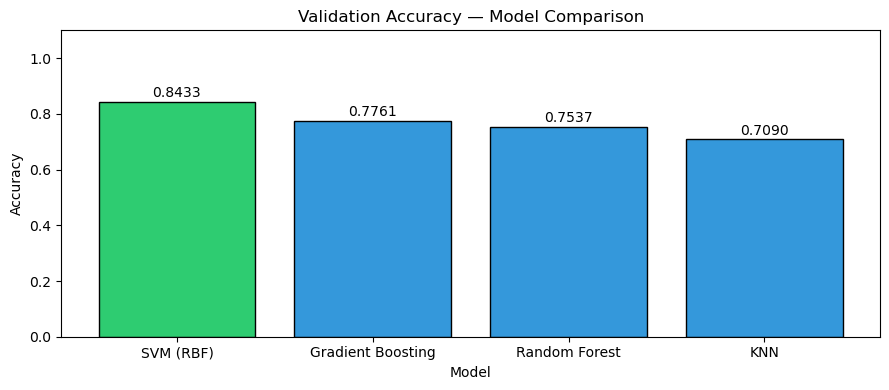


Best model: SVM (RBF) with accuracy 0.8433


In [19]:
# ---- Summary table ----
summary = pd.DataFrame({
    'Model'               : list(results.keys()),
    'Validation Accuracy' : [v['accuracy'] for v in results.values()]
}).sort_values('Validation Accuracy', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

# ---- Bar chart ----
plt.figure(figsize=(9, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(summary))]
bars   = plt.bar(summary['Model'], summary['Validation Accuracy'], color=colors, edgecolor='black')

for bar, val in zip(bars, summary['Validation Accuracy']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha='center', va='bottom', fontsize=10
    )

plt.ylim(0, 1.1)
plt.title("Validation Accuracy — Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# Identify best model
best_name  = summary.iloc[0]['Model']
best_model = results[best_name]['model']
print(f"\nBest model: {best_name} with accuracy {summary.iloc[0]['Validation Accuracy']:.4f}")

## 8. Detailed Evaluation — Best Model

We evaluate the best model with a confusion matrix and full classification report.

Classification Report — SVM (RBF) (Validation Set)
              precision    recall  f1-score   support

      glioma       0.82      0.90      0.86       116
  meningioma       0.79      0.70      0.75       115
    no_tumor       0.81      0.84      0.82        55
   pituitary       0.93      0.93      0.93       116

    accuracy                           0.84       402
   macro avg       0.84      0.84      0.84       402
weighted avg       0.84      0.84      0.84       402



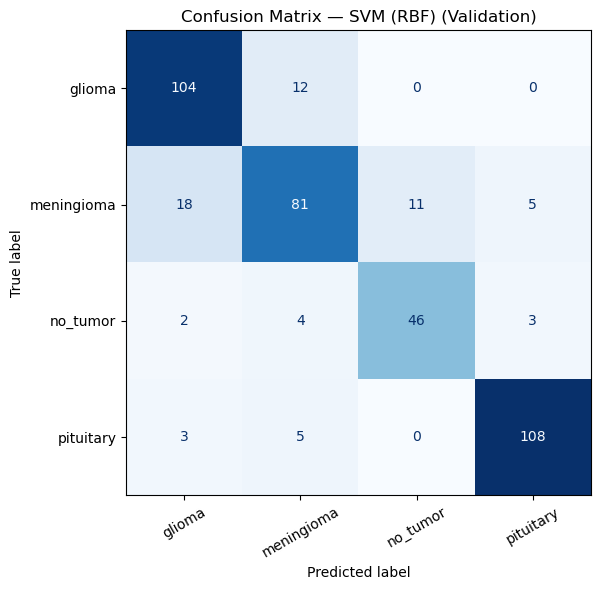

In [20]:
# ---- Classification report on validation set ----
y_val_pred = results[best_name]['predictions']

print(f"Classification Report — {best_name} (Validation Set)")
print("=" * 55)
print(classification_report(
    y_val, y_val_pred,
    target_names = le.classes_
))

# ---- Confusion matrix ----
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix — {best_name} (Validation)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Final Evaluation on Test Set

The test set has been completely unseen during training and validation.
This gives the truest measure of model generalization.

Test Set Accuracy (SVM (RBF)): 0.8586

              precision    recall  f1-score   support

      glioma       0.85      0.90      0.87       248
  meningioma       0.81      0.77      0.79       247
    no_tumor       0.78      0.76      0.77       119
   pituitary       0.96      0.95      0.95       249

    accuracy                           0.86       863
   macro avg       0.85      0.85      0.85       863
weighted avg       0.86      0.86      0.86       863



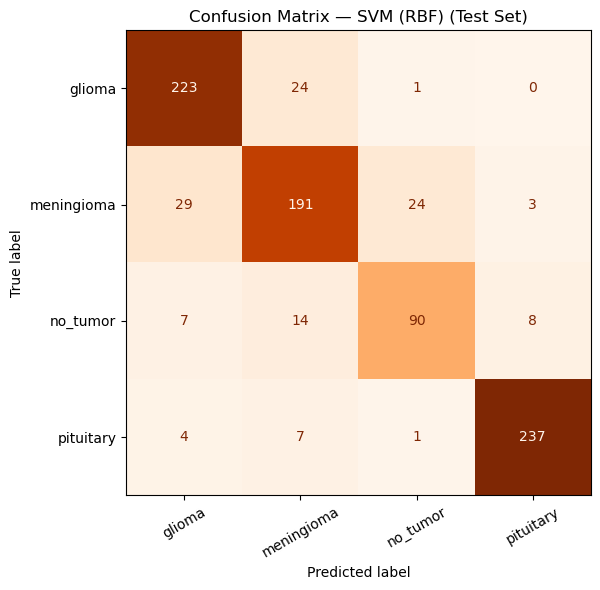

In [21]:
# Predict on the held-out test folder
y_test_pred = best_model.predict(X_tst_pca)
test_acc    = accuracy_score(y_test_encoded, y_test_pred)

print(f"Test Set Accuracy ({best_name}): {test_acc:.4f}")
print()
print(classification_report(
    y_test_encoded, y_test_pred,
    target_names = le.classes_
))

# ---- Test confusion matrix ----
cm_test = confusion_matrix(y_test_encoded, y_test_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)
disp.plot(cmap='Oranges', ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix — {best_name} (Test Set)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 10. Predict on a Single Image

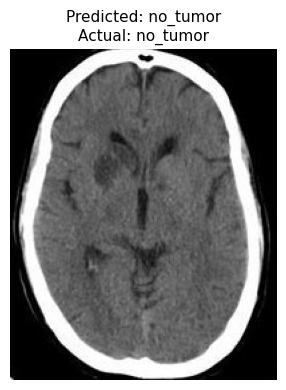

In [22]:
def predict_single_image(image_path, model, pca, label_encoder, img_size=IMG_SIZE):
    """
    Predict the tumor class for a single MRI image.

    Parameters
    ----------
    image_path    : str            — full path to the image file
    model         : trained model  — sklearn classifier
    pca           : fitted PCA     — same PCA used during training
    label_encoder : LabelEncoder   — to decode predicted integer back to class name
    img_size      : tuple          — must match training image size

    Returns
    -------
    str — predicted class name
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img      = cv2.resize(img, img_size)
    img_flat = img.flatten() / 255.0
    img_pca  = pca.transform([img_flat])
    pred_int = model.predict(img_pca)[0]

    return label_encoder.inverse_transform([pred_int])[0]


# ---- Demo: predict first image from test folder ----
sample_path = os.path.join(TEST_FOLDER, test_files[0])
prediction  = predict_single_image(sample_path, best_model, pca, le)
actual      = y_test_raw[0]

# Display image with prediction
img_display = cv2.imread(sample_path)
img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.axis('off')
plt.title(f"Predicted: {prediction}\nActual: {actual}", fontsize=11)
plt.tight_layout()
plt.show()

---

## Summary

| Step | Description |
|---|---|
| Data loading | Images read from `train/` and `test/` folders; labels extracted from filenames |
| Preprocessing | Resize to 64x64, normalize to [0,1], PCA to 100 components |
| Models trained | Random Forest, SVM (RBF), Gradient Boosting, KNN |
| Best model | Selected by highest validation accuracy |
| Final evaluation | Tested on held-out test folder |
| Persistence | Model, PCA, and encoder saved as `.pkl` files |

### Possible Improvements

- Increase `IMG_SIZE` to `(128, 128)` for richer features
- Use deep learning (CNN via PyTorch or TensorFlow) for significantly higher accuracy
- Apply data augmentation (rotation, flipping) to increase training diversity
- Tune hyperparameters using `GridSearchCV` or `RandomizedSearchCV`